# Nhật Huy — C3 DistilBERT: full ba seed và demo

Notebook hướng dẫn theo từng bước từ dữ liệu đến kết quả, ngưỡng và phân tích lỗi.
**Mọi bảng thực nghiệm được đọc/tính lại từ các run thật trên official train/validation.**
Không có dữ liệu tổng hợp hoặc số liệu tự điền. Không đánh giá test, không chọn người thắng C1/C2/C3.

Pilot 1.024/256 mẫu trước đây chỉ là kiểm kỹ thuật. Notebook này dùng **43.410 train / 5.426 validation**,
ba seed **42, 123, 2026** và cấu hình đã ghi trước khi huấn luyện trong `full/protocol.json`.
Mặc định Run All kiểm lại các kết quả đã có; không tự chạy thêm ba lượt train dài.


## 1. Mở đúng môi trường và thư mục repo

In [1]:
from pathlib import Path
import sys
ROOT=Path.cwd().resolve()
if not (ROOT/'src').exists(): ROOT=ROOT.parent
assert (ROOT/'src/c3.py').exists()
sys.path.insert(0,str(ROOT))
from src.c3 import read_json, prepare_frames, EmotionDataset, make_loader, load_bundle
from src.data import multi_hot, sha256
from src.metrics import evaluate_multilabel
from src.baseline import load_aligned_scores
from src.c3_thresholds import predict_c3, load_c3_thresholds
import numpy as np
import pandas as pd
import torch
from IPython.display import display
torch.set_num_threads(4)
REPORT=ROOT/'reports/c3_distilbert/full'
protocol=read_json(REPORT/'protocol.json')
print('Python:',sys.version.split()[0], '| torch:',torch.__version__)
print('CUDA:',torch.cuda.is_available())
display(pd.DataFrame(read_json(ROOT/'reports/c3_distilbert/environment.json')['packages'].items(),columns=['Thư viện','Phiên bản']))

D:\Nam_3\HK1\NLP\LT\goemotions-multilabel-classification\.venv-huy\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.12.6 | torch: 2.11.0+cu128


CUDA: True


,Thư viện,Phiên bản
0,torch,2.11.0+cu128
1,transformers,4.57.6
2,numpy,2.3.5
3,pandas,2.3.3
4,pyarrow,21.0.0
5,scikit-learn,1.7.2
6,streamlit,1.55.0
7,tokenizers,0.22.2


## 2. Đọc cấu hình đã khóa trước khi chạy

Giữ nguyên cấu hình giữa các seed: DistilBERT-base-uncased, max length 128, lr 2e-5,
3 epoch, batch 16. Model và dataset có revision ghim. Khác pilot: batch vật lý 16,
không cần tích lũy; kiểm bộ nhớ trước full được ghi ở `full_preflight.json`.
Checkpoint chọn bằng Macro-F1 validation @0,5; khi hòa giữ epoch sớm hơn.


In [2]:
config=protocol['config']
assert sha256(ROOT/'configs/distilbert_full.json')==protocol['config_sha256']
display(pd.DataFrame(config.items(),columns=['Tham số','Giá trị']).astype(str))
print('Seeds:',protocol['seeds'])
print('Chọn checkpoint:',protocol['checkpoint_selection'])
print('Không dùng test:',not protocol['test_used'])

,Tham số,Giá trị
0,mode,full
1,model_id,distilbert/distilbert-base-uncased
2,revision,12040accade4e8a0f71eabdb258fecc2e7e948be
3,seed,42
4,subset_seed,2026
5,train_limit,None
6,validation_limit,None
7,epochs,3
8,max_length,128
9,batch_size,16


Seeds: [42, 123, 2026]
Chọn checkpoint: highest validation macro_f1 @0.5; earliest epoch if tied
Không dùng test: True


## 3. Đọc dữ liệu thật và kiểm ID/mapping

`prepare_frames` chỉ đọc train/validation và kiểm hash nguồn. Giữ nguyên văn bản và official split.
Không oversampling, không thêm câu nhân tạo. Phần EDA toàn bộ dữ liệu nằm trong notebook EDA riêng.


In [3]:
frames,names,manifest=prepare_frames(config)
display(pd.DataFrame([{'split':s,'số mẫu':len(df),'ID duy nhất':df.id.nunique()} for s,df in frames.items()]))
assert len(frames['train'])==43410 and len(frames['validation'])==5426
assert not (set(frames['train'].id)&set(frames['validation'].id))
example=frames['train'].head(5).copy()
example['label_names']=example.labels.apply(lambda labels:[names[i] for i in labels])
display(example[['id','text','labels','label_names']])

,split,số mẫu,ID duy nhất
0,train,43410,43410
1,validation,5426,5426


,id,text,labels,label_names
0,eebbqej,My favourite food is anything I didn't have to...,[27],[neutral]
1,ed00q6i,"Now if he does off himself, everyone will thin...",[27],[neutral]
2,eezlygj,WHY THE FUCK IS BAYLESS ISOING,[2],[anger]
3,ed7ypvh,To make her feel threatened,[14],[fear]
4,ed0bdzj,Dirty Southern Wankers,[3],[annoyance]


## 4. Chuyển nhãn sang multi-hot float32

Mỗi mẫu có 28 vị trí; một hoặc nhiều vị trí bằng 1. Target được đưa trực tiếp vào
BCEWithLogitsLoss, không biến thành một class index.


In [4]:
targets={s:multi_hot(df.labels.tolist(),len(names)).astype(np.float32) for s,df in frames.items()}
print({s:(y.shape,str(y.dtype)) for s,y in targets.items()})
display(pd.DataFrame({'label_id':range(28),'label':names,'train_support':targets['train'].sum(0).astype(int),
                      'validation_support':targets['validation'].sum(0).astype(int)}))
print('Multi-hot mẫu đầu:',targets['train'][0].tolist())

{'train': ((43410, 28), 'float32'), 'validation': ((5426, 28), 'float32')}


,label_id,label,train_support,validation_support
0,0,admiration,4130,488
1,1,amusement,2328,303
2,2,anger,1567,195
3,3,annoyance,2470,303
4,4,approval,2939,397
5,5,caring,1087,153
6,6,confusion,1368,152
7,7,curiosity,2191,248
8,8,desire,641,77
9,9,disappointment,1269,163


Multi-hot mẫu đầu: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]


## 5. Tokenize và xem batch thật

Đọc tokenizer của checkpoint C3 đại diện (seed có Macro-F1 validation @0,5 cao nhất trong C3).
Đây chưa phải kiến trúc thắng của nhóm. Padding theo batch và truncation ở 128 token.


In [5]:
selected=read_json(REPORT/'representative_c3.json')
RUN=ROOT/selected['run']
from transformers import AutoTokenizer
tokenizer=AutoTokenizer.from_pretrained(RUN/'best',local_files_only=True)
dataset=EmotionDataset(frames['train'].head(16),tokenizer,config['max_length'])
batch=next(iter(make_loader(dataset,tokenizer,config['batch_size'])))
display(pd.DataFrame([{'tensor':k,'shape':str(tuple(v.shape)),'dtype':str(v.dtype)} for k,v in batch.items()]))
print(tokenizer.convert_ids_to_tokens(batch['input_ids'][0].tolist()))
assert batch['labels'].dtype==torch.float32 and batch['labels'].shape[1]==28

,tensor,shape,dtype
0,input_ids,"(16, 42)",torch.int64
1,attention_mask,"(16, 42)",torch.int64
2,labels,"(16, 28)",torch.float32


['[CLS]', 'my', 'favourite', 'food', 'is', 'anything', 'i', 'didn', "'", 't', 'have', 'to', 'cook', 'myself', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


## 6. Kiểm loss bằng checkpoint và nhãn thật

Luồng: tokenizer → encoder → đầu phân loại 28 logits → BCEWithLogitsLoss khi học.
Sigmoid chỉ chuyển logits thành scores khi suy luận. Cell sau chỉ forward để kiểm loss,
không cập nhật trọng số, không tạo dữ liệu giả.


In [6]:
bundle=load_bundle(RUN,'cpu')
with torch.inference_mode():
    result=bundle['model'](**batch)
    expected=torch.nn.functional.binary_cross_entropy_with_logits(result.logits,batch['labels'])
torch.testing.assert_close(result.loss,expected)
print('Shape logits:',tuple(result.logits.shape))
print('Loss trên batch train thật để kiểm công thức:',float(result.loss))
print('PASS: loss của model đúng BCEWithLogitsLoss')

Shape logits: (16, 28)
Loss trên batch train thật để kiểm công thức: 0.06122599169611931
PASS: loss của model đúng BCEWithLogitsLoss


## 7. Cách chạy ba seed

Runner đọc cấu hình, kiểm dữ liệu → seed → tokenizer/model → AdamW → train/validation từng epoch
→ giữ best epoch → scores/metrics → nạp lại checkpoint để kiểm tính nhất quán.
AMP và gradient checkpointing được bật; CPU threads=4. AdamW không decay bias/LayerNorm,
warmup 10%, linear decay, clip gradient 1,0. Xem toàn bộ vòng lặp tại `scripts/train_distilbert.py`.

Lệnh đã dùng: `python -m scripts.run_c3_full`. Nó chạy tuần tự để các seed không tranh GPU;
run hoàn thành và đúng hash được kiểm rồi bỏ qua, không ghi đè. Chạy lại một thí nghiệm riêng
cần `--output` mới với `scripts.train_distilbert`; không ghép lẫn với ba seed đã khóa.


In [7]:
import subprocess
print('Lệnh từ interpreter hiện tại:')
print(subprocess.list2cmdline([sys.executable,'-u','-m','scripts.run_c3_full']))
print('Cell này không khởi động train.')
for seed in protocol['seeds']:
    log=REPORT/f'train_seed_{seed}.log'
    print(seed,':', '\n'.join(log.read_text(encoding='utf-8').splitlines()[-3:]))

Lệnh từ interpreter hiện tại:
D:\Nam_3\HK1\NLP\LT\goemotions-multilabel-classification\.venv-huy\Scripts\python.exe -u -m scripts.run_c3_full
Cell này không khởi động train.
42 : epoch=3, validation Macro-F1@0.5=0.40326
PASS: full complete, best epoch=3, reload diff=0
D:\Nam_3\HK1\NLP\LT\goemotions-multilabel-classification\data\processed\c3_distilbert\full\seed_42
123 : epoch=3, validation Macro-F1@0.5=0.41133
PASS: full complete, best epoch=3, reload diff=0
D:\Nam_3\HK1\NLP\LT\goemotions-multilabel-classification\data\processed\c3_distilbert\full\seed_123
2026 : epoch=3, validation Macro-F1@0.5=0.40367
PASS: full complete, best epoch=3, reload diff=0
D:\Nam_3\HK1\NLP\LT\goemotions-multilabel-classification\data\processed\c3_distilbert\full\seed_2026


## 8. Xem lịch sử học và tài nguyên của cả ba seed

,seed,epoch,train_loss,validation_macro_f1,validation_micro_f1,epoch_train_and_eval_seconds
0,42,1,0.163071,0.263345,0.512500,491.594978
1,42,2,0.085828,0.372952,0.554580,454.450361
2,42,3,0.075794,0.403256,0.568935,464.302000
3,123,1,0.162743,0.269107,0.507444,452.904308
4,123,2,0.086294,0.386296,0.564292,466.958364
5,123,3,0.076224,0.411325,0.576176,457.801856
6,2026,1,0.161807,0.243192,0.518810,648.382768
7,2026,2,0.086021,0.382368,0.563892,642.638549
8,2026,3,0.075922,0.403670,0.573720,664.372091


,seed,skipped_amp_steps,best_epoch,optimizer_steps,effective_batch_size,trainable_parameters,fit_and_validation_seconds,peak_cuda_allocated_mib,peak_cuda_reserved_mib,reload_max_abs_score_diff
0,42,1,3,8141,16,66975004,1411.581204,1363.134766,1476.0,0.0
1,123,1,3,8141,16,66975004,1383.677994,1363.791016,1476.0,0.0
2,2026,1,3,8141,16,66975004,1957.309895,1363.791016,1476.0,0.0


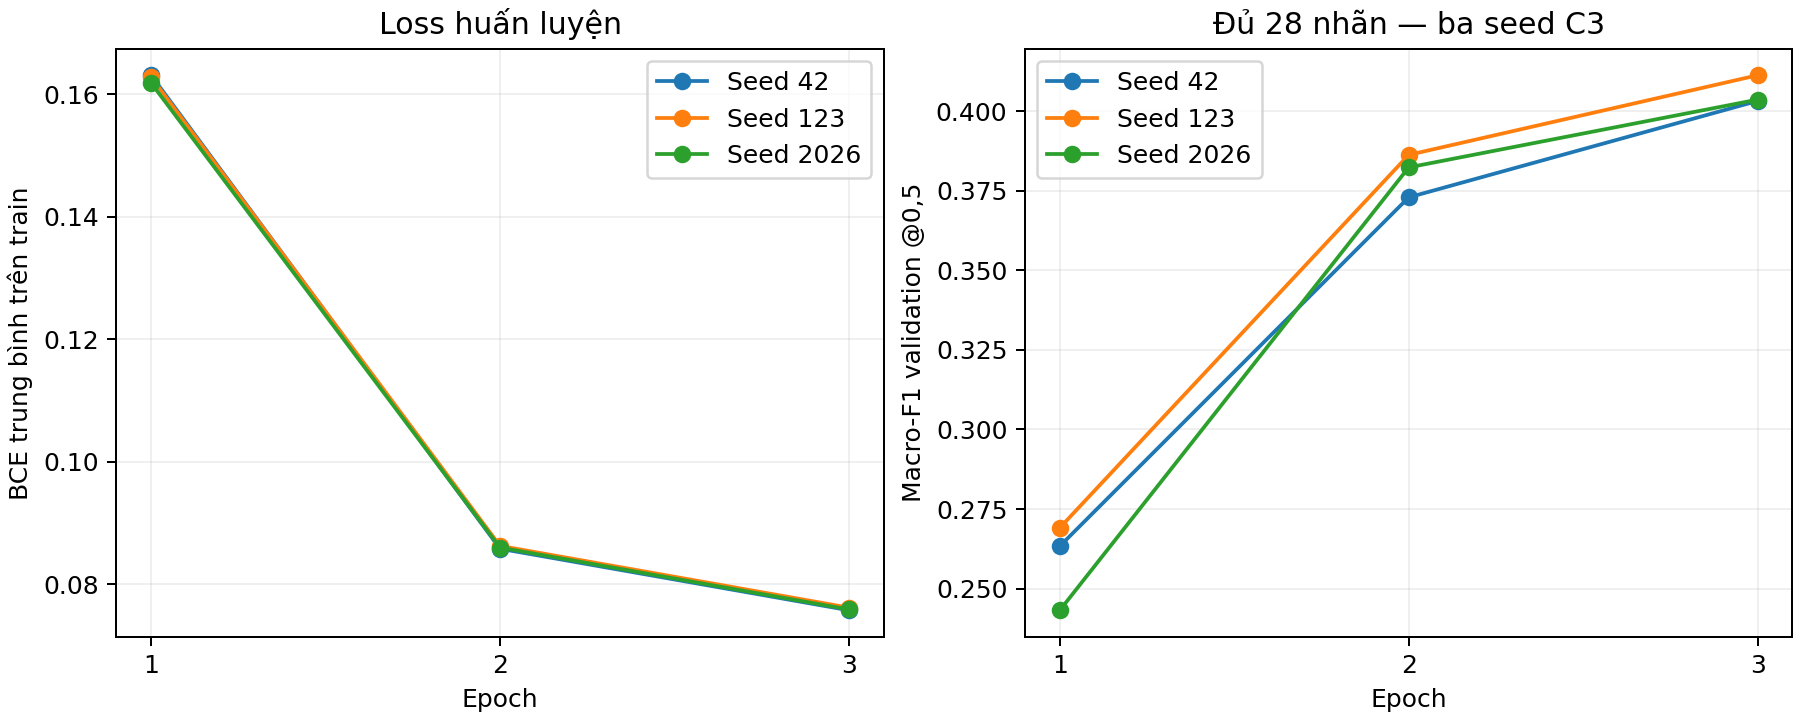

PASS: best epoch đúng quy tắc, đủ dữ liệu, không dùng test.


In [8]:
history=pd.read_csv(REPORT/'history_all_seeds.csv')
display(history)
display(pd.read_csv(REPORT/'resources_all_seeds.csv'))
from IPython.display import Image
display(Image(filename=str(REPORT/'learning_curves.png')))
for seed in protocol['seeds']:
    meta=read_json(ROOT/f'data/processed/c3_distilbert/full/seed_{seed}/run.json')
    expected_epoch=int(history[history.seed==seed].sort_values(['validation_macro_f1','epoch'],ascending=[False,True]).iloc[0].epoch)
    assert meta['best_epoch']==expected_epoch
    assert meta['n_train']==43410 and meta['n_validation']==5426 and not meta['test_used']
print('PASS: best epoch đúng quy tắc, đủ dữ liệu, không dùng test.')

## 9. Ghép scores theo ID và tính lại metrics

Không giả định file scores có cùng thứ tự dòng với dữ liệu. Ghép bằng ID, kiểm label_names,
shape N×28 và scores [0,1]. Tính lại đủ metrics bằng hàm chung, so với JSON đã lưu.


In [9]:
all_scores={}
for seed in protocol['seeds']:
    run=ROOT/f'data/processed/c3_distilbert/full/seed_{seed}'
    scores=load_aligned_scores(run/'validation_scores.npz',frames['validation'].id,names)
    recalculated=evaluate_multilabel(targets['validation'],scores,names,.5)
    assert recalculated==read_json(run/'validation_metrics.json')
    all_scores[seed]=scores
print('PASS: ID, mapping và metrics của cả ba seed khớp.')

PASS: ID, mapping và metrics của cả ba seed khớp.


## 10. Kết quả cơ sở: từng seed và mean ± sample std

Tính Macro-F1 trên đủ 28 nhãn, zero_division=0. Mean/std dùng cả ba seed, `ddof=1`.
Không lấy seed cao nhất để thay cho kết quả trung bình kiến trúc.


In [10]:
from scripts.summarize_distilbert import summarize
runs=[ROOT/f'data/processed/c3_distilbert/full/seed_{seed}' for seed in protocol['seeds']]
rows,stats=summarize(runs)
display(rows)
display(stats)
assert len(rows)==3
print('Seed C3 đại diện:',selected['seed'],'; kiến trúc thắng toàn nhóm:',selected['architecture_winner'])

,seed,best_epoch,macro_f1,micro_f1,macro_precision,macro_recall,micro_precision,micro_recall,hamming_loss
0,42,3,0.403256,0.568935,0.572258,0.343198,0.709006,0.475078,0.030231
1,123,3,0.411325,0.576176,0.576251,0.351337,0.712373,0.483699,0.029883
2,2026,3,0.403670,0.573720,0.570269,0.344497,0.708266,0.482132,0.030087


,metric,mean,sample_std,n
0,macro_f1,0.406084,0.004544,3
1,micro_f1,0.572944,0.003683,3
2,macro_precision,0.572926,0.003046,3
3,macro_recall,0.346344,0.004372,3
4,micro_precision,0.709882,0.002189,3
5,micro_recall,0.480303,0.004592,3
6,hamming_loss,0.030067,0.000175,3


Seed C3 đại diện: 123 ; kiến trúc thắng toàn nhóm: None


## 11. Metrics từng nhãn và nhãn hiếm đã định nghĩa từ train

In [11]:
per_label=pd.read_csv(REPORT/'per_label_all_seeds.csv')
display(per_label[(per_label.seed==selected['seed'])&(per_label['mode']=='fixed_0.5')])
print('Nhãn hiếm đã định nghĩa trước:',protocol['rare_labels_train_defined'])

,seed,mode,train_support,rare_train_defined,label_id,label,support,predicted_support,tp,fp,fn,tn,precision,recall,f1
56,123,fixed_0.5,4130,False,0,admiration,488,465,348,117,140,4821,0.748387,0.713115,0.730325
57,123,fixed_0.5,2328,False,1,amusement,303,323,245,78,58,5045,0.758514,0.808581,0.782748
58,123,fixed_0.5,1567,False,2,anger,195,125,73,52,122,5179,0.584000,0.374359,0.456250
59,123,fixed_0.5,2470,False,3,annoyance,303,66,37,29,266,5094,0.560606,0.122112,0.200542
60,123,fixed_0.5,2939,False,4,approval,397,134,85,49,312,4980,0.634328,0.214106,0.320151
61,123,fixed_0.5,1087,False,5,caring,153,69,44,25,109,5248,0.637681,0.287582,0.396396
62,123,fixed_0.5,1368,False,6,confusion,152,59,38,21,114,5253,0.644068,0.250000,0.360190
63,123,fixed_0.5,2191,False,7,curiosity,248,165,93,72,155,5106,0.563636,0.375000,0.450363
64,123,fixed_0.5,641,False,8,desire,77,46,32,14,45,5335,0.695652,0.415584,0.520325
65,123,fixed_0.5,1269,False,9,disappointment,163,13,5,8,158,5255,0.384615,0.030675,0.056818


Nhãn hiếm đã định nghĩa trước: ['grief', 'pride', 'relief', 'nervousness', 'embarrassment']


## 12. Nâng cao đúng phạm vi: ngưỡng riêng cho từng nhãn

Mỗi seed dùng validation scores của chính checkpoint đó. Lưới 0,05 đến 0,95, bước 0,05;
hòa F1 thì gần 0,5 nhất, tiếp tục hòa chọn ngưỡng lớn hơn. Không lấy ngưỡng baseline A.
Giữ nguyên bảng cơ sở @0,5; không train thêm weighting hoặc mô hình khác.

**Tuned-validation được chọn và đo trên cùng validation nên có thể lạc quan.**
Không diễn giải là cải thiện test hoặc đánh giá độc lập.


In [12]:
threshold_table=[]
for seed,run in zip(protocol['seeds'],runs):
    meta=read_json(run/'run.json')
    values=load_c3_thresholds(run,meta,'per_label')
    for name,value in zip(names,values): threshold_table.append({'seed':seed,'label':name,'threshold':value})
display(pd.DataFrame(threshold_table).pivot(index='label',columns='seed',values='threshold').reindex(names))
display(pd.read_csv(REPORT/'threshold_comparison_runs.csv'))
display(pd.read_csv(REPORT/'threshold_comparison_mean_std.csv'))

seed,42,123,2026
label,,,
admiration,0.45,0.40,0.40
amusement,0.35,0.25,0.45
anger,0.30,0.35,0.30
annoyance,0.20,0.20,0.15
approval,0.15,0.20,0.20
caring,0.20,0.35,0.20
confusion,0.20,0.25,0.25
curiosity,0.15,0.25,0.20
desire,0.35,0.15,0.20


,seed,mode,macro_f1,micro_f1,macro_precision,macro_recall,micro_precision,micro_recall,hamming_loss,empty_prediction_count
0,42,fixed_0.5,0.403256,0.568935,0.572258,0.343198,0.709006,0.475078,0.030231,1299
1,42,per_label_tuned_on_validation,0.512029,0.600254,0.510012,0.542656,0.545175,0.667712,0.037347,64
2,123,fixed_0.5,0.411325,0.576176,0.576251,0.351337,0.712373,0.483699,0.029883,1238
3,123,per_label_tuned_on_validation,0.509678,0.607020,0.545091,0.518848,0.558971,0.664107,0.036109,68
4,2026,fixed_0.5,0.403670,0.573720,0.570269,0.344497,0.708266,0.482132,0.030087,1240
5,2026,per_label_tuned_on_validation,0.510227,0.600086,0.518457,0.524693,0.553321,0.655486,0.036688,85


,mode,metric,mean,sample_std,n
0,fixed_0.5,macro_f1,0.406084,0.004544,3
1,fixed_0.5,micro_f1,0.572944,0.003683,3
2,fixed_0.5,macro_precision,0.572926,0.003046,3
3,fixed_0.5,macro_recall,0.346344,0.004372,3
4,fixed_0.5,micro_precision,0.709882,0.002189,3
5,fixed_0.5,micro_recall,0.480303,0.004592,3
6,fixed_0.5,hamming_loss,0.030067,0.000175,3
7,per_label_tuned_on_validation,macro_f1,0.510645,0.001230,3
8,per_label_tuned_on_validation,micro_f1,0.602453,0.003956,3
9,per_label_tuned_on_validation,macro_precision,0.524520,0.018308,3


## 13. Nhãn hiếm trước/sau tuning

Giữ cả nhãn không tăng hoặc giảm; phân biệt support validation với train support.
Không dùng số liệu pilot để kết luận hiệu quả nhãn hiếm.


,label,mode,train_support,validation_support,f1_mean,f1_std,precision_mean,recall_mean
0,embarrassment,fixed_0.5,303,35,0.334511,0.056319,0.714646,0.219048
1,grief,fixed_0.5,77,13,0.000000,0.000000,0.000000,0.000000
2,nervousness,fixed_0.5,164,21,0.000000,0.000000,0.000000,0.000000
3,pride,fixed_0.5,111,15,0.000000,0.000000,0.000000,0.000000
4,relief,fixed_0.5,153,18,0.000000,0.000000,0.000000,0.000000
5,embarrassment,per_label_tuned_on_validation,303,35,0.546730,0.014079,0.705758,0.447619
6,grief,per_label_tuned_on_validation,77,13,0.000000,0.000000,0.000000,0.000000
7,nervousness,per_label_tuned_on_validation,164,21,0.385569,0.013978,0.579545,0.349206
8,pride,per_label_tuned_on_validation,111,15,0.594517,0.063819,0.915344,0.444444
9,relief,per_label_tuned_on_validation,153,18,0.048780,0.084490,0.043478,0.055556


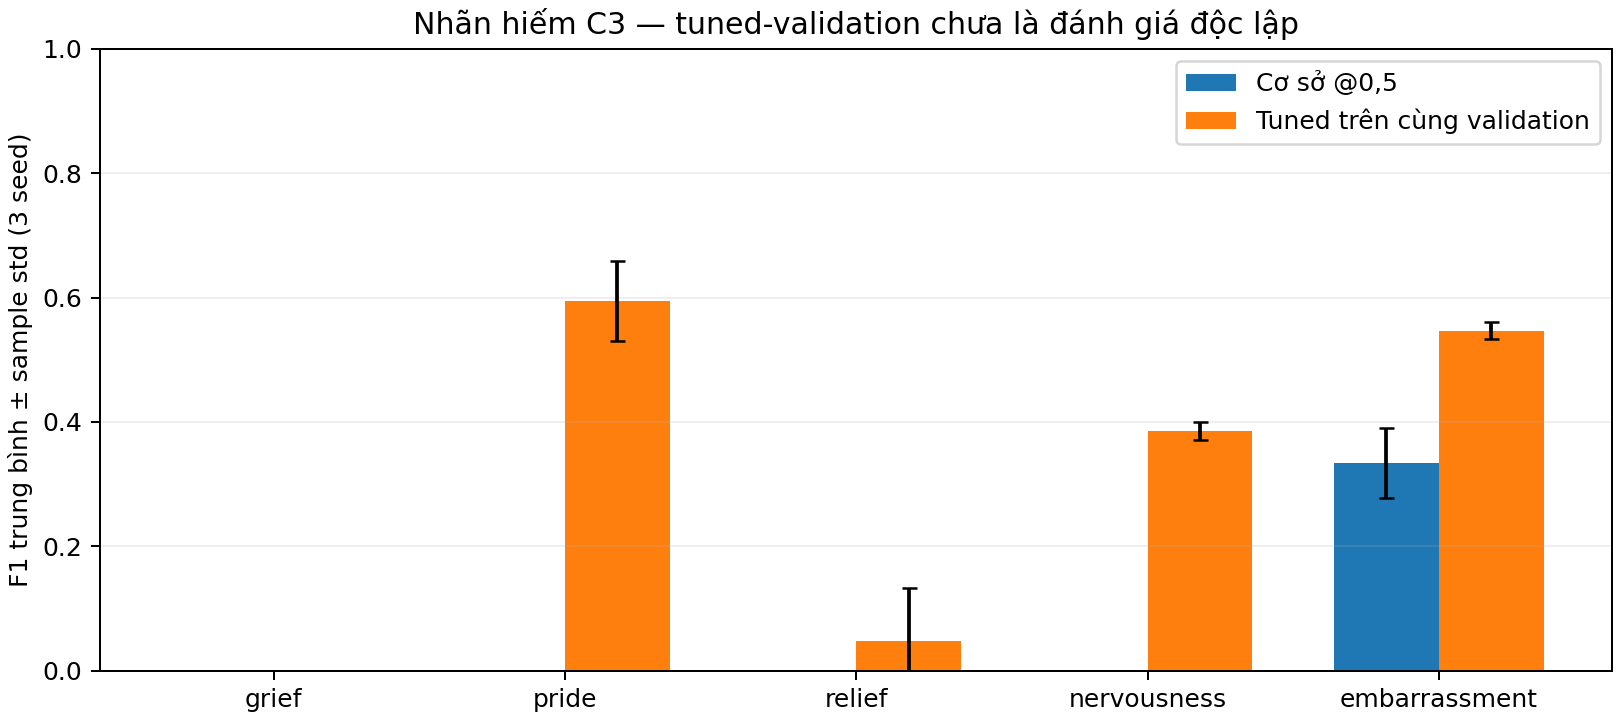

,seed,mode,label,train_support,support,precision,recall,f1
0,42,fixed_0.5,embarrassment,303,35,0.666667,0.171429,0.272727
1,42,fixed_0.5,grief,77,13,0.000000,0.000000,0.000000
2,42,fixed_0.5,nervousness,164,21,0.000000,0.000000,0.000000
3,42,fixed_0.5,pride,111,15,0.000000,0.000000,0.000000
4,42,fixed_0.5,relief,153,18,0.000000,0.000000,0.000000
5,42,per_label_tuned_on_validation,embarrassment,303,35,0.640000,0.457143,0.533333
6,42,per_label_tuned_on_validation,grief,77,13,0.000000,0.000000,0.000000
7,42,per_label_tuned_on_validation,nervousness,164,21,0.375000,0.428571,0.400000
8,42,per_label_tuned_on_validation,pride,111,15,0.888889,0.533333,0.666667
9,42,per_label_tuned_on_validation,relief,153,18,0.000000,0.000000,0.000000


In [13]:
display(pd.read_csv(REPORT/'rare_labels_mean_std.csv'))
display(Image(filename=str(REPORT/'rare_labels_f1.png')))
display(pd.read_csv(REPORT/'rare_labels_before_after.csv')[['seed','mode','label','train_support','support','precision','recall','f1']])

## 14. Phân tích lỗi C3 trên mẫu thật

Ba nhóm kiểm tra: FN và FP trong cùng câu; bỏ sót một phần nhãn thật của câu đa nhãn;
lỗi nhãn hiếm/neutral. Nhóm có thể giao nhau, không cộng số nhóm để ra tổng câu sai.
FN/FP cùng câu chưa đủ chứng minh hai cảm xúc gần nghĩa; cần đọc nội dung thủ công.
Ví dụ được lấy theo ID tăng dần trong mỗi nhóm, không chỉ chọn lỗi phù hợp nhận định có sẵn.
Đối chiếu ba C cần thêm scores C1/C2 của các bạn; ở đây chỉ phân tích C3.
Đọc bảy mẫu có nhận xét thủ công tại
[ERROR_ANALYSIS.md](../reports/c3_distilbert/full/ERROR_ANALYSIS.md): ranh giới cảm xúc gần nghĩa,
bỏ sót một phần nhãn, diễn đạt hàm ý/neutral. Các nhận xét không chứng minh nguyên nhân lỗi.


In [14]:
display(pd.read_csv(REPORT/'error_group_counts.csv'))
examples=read_json(REPORT/'error_examples.json')
display(pd.DataFrame([{k:v for k,v in e.items() if k!='scores'} for e in examples]).groupby('group',sort=False).head(3))
display(pd.read_csv(REPORT/f"error_pairs_seed_{selected['seed']}.csv").head(12))
for e in examples:
    row=frames['validation'].set_index('id').loc[e['id']]
    assert row.text==e['text'] and [names[i] for i in row.labels]==e['true_labels']
print('PASS: ví dụ/ID/nhãn thật đều khớp dataset.')

,seed,group,n_samples,n_validation,note
0,42,FN_va_FP_cung_cau,1167,5426,Groups may overlap; counts are not additive
1,42,thieu_mot_phan_nhan_that,458,5426,Groups may overlap; counts are not additive
2,42,sai_nhan_hiem_hoac_neutral,1255,5426,Groups may overlap; counts are not additive
3,123,FN_va_FP_cung_cau,1168,5426,Groups may overlap; counts are not additive
4,123,thieu_mot_phan_nhan_that,480,5426,Groups may overlap; counts are not additive
5,123,sai_nhan_hiem_hoac_neutral,1218,5426,Groups may overlap; counts are not additive
6,2026,FN_va_FP_cung_cau,1184,5426,Groups may overlap; counts are not additive
7,2026,thieu_mot_phan_nhan_that,463,5426,Groups may overlap; counts are not additive
8,2026,sai_nhan_hiem_hoac_neutral,1224,5426,Groups may overlap; counts are not additive


,group,seed,id,text,true_labels,predicted_labels,missed_labels,extra_labels,threshold
0,FN_va_FP_cung_cau,123,eczg2g7,I'm in the Central Time Zone in the US so I ha...,[neutral],[joy],[neutral],[joy],0.5
1,FN_va_FP_cung_cau,123,eczh1pf,[NAME] speed!,[admiration],[neutral],[admiration],[neutral],0.5
2,FN_va_FP_cung_cau,123,eczj0in,Kinda let down tbh,"[annoyance, disappointment]",[neutral],"[annoyance, disappointment]",[neutral],0.5
12,thieu_mot_phan_nhan_that,123,eczdu8p,"Oooh yes, great idea. Too bad there aren't any...","[admiration, disapproval]",[admiration],[disapproval],[],0.5
13,thieu_mot_phan_nhan_that,123,eczfzzk,I drove off 170 onto 40 and was surprised by t...,"[amusement, surprise]",[surprise],[amusement],[],0.5
14,thieu_mot_phan_nhan_that,123,eczhjuj,it sounds like you're setting up for a good 2...,"[approval, optimism]",[optimism],[approval],[],0.5
24,sai_nhan_hiem_hoac_neutral,123,eczdhfb,"You still look cranky, goodnight.",[neutral],[],[neutral],[],0.5
25,sai_nhan_hiem_hoac_neutral,123,eczg2g7,I'm in the Central Time Zone in the US so I ha...,[neutral],[joy],[neutral],[joy],0.5
26,sai_nhan_hiem_hoac_neutral,123,eczh1pf,[NAME] speed!,[admiration],[neutral],[admiration],[neutral],0.5


,missed_label,extra_label,count,missed_label_total_fn,fraction_of_fn,example_row
0,approval,neutral,87,312,0.278846,106
1,disapproval,neutral,71,241,0.294606,22
2,annoyance,neutral,53,266,0.199248,197
3,neutral,curiosity,45,711,0.063291,0
4,realization,neutral,32,113,0.283186,62
5,neutral,approval,29,711,0.040788,279
6,caring,neutral,27,109,0.247706,498
7,curiosity,neutral,27,155,0.174194,186
8,neutral,amusement,27,711,0.037975,1185
9,neutral,admiration,26,711,0.036568,18


PASS: ví dụ/ID/nhãn thật đều khớp dataset.


## 15. Dự đoán và demo bằng ví dụ có thật

Dùng mẫu đầu validation, không chỉnh câu để làm đẹp đầu ra. Cơ sở và tuned giữ nguyên scores,
chỉ thay ngưỡng. Chỉ nạp ngưỡng khi hash model/scores và seed khớp.


In [15]:
text=frames['validation'].text.iloc[0]
print('ID:',frames['validation'].id.iloc[0], '\nText:',text)
fixed=predict_c3(bundle,[text],RUN,'fixed')[0]
tuned=predict_c3(bundle,[text],RUN,'per_label')[0]
print('Nhãn thật:',[names[i] for i in frames['validation'].labels.iloc[0]])
print('Cơ sở:',fixed['labels'],'| Tuned:',tuned['labels'])
assert fixed['scores']==tuned['scores']
display(pd.DataFrame(fixed['scores'].items(),columns=['Nhãn','Score']).sort_values('Score',ascending=False))
print('Kiểm input rỗng:')
try: predict_c3(bundle,['  '],RUN)
except ValueError as exc: print(exc)
empty_indices=np.flatnonzero((all_scores[selected['seed']]>=.5).sum(1)==0)
print('Số mẫu validation không nhãn nào đạt 0,5:',len(empty_indices))
if len(empty_indices):
    i=int(empty_indices[0])
    actual=predict_c3(bundle,[frames['validation'].text.iloc[i]],RUN)[0]
    print('Ví dụ thật:',frames['validation'].id.iloc[i],actual['text'],actual['labels'])

ID: edgurhb 
Text: Is this in New Orleans?? I really feel like this is New Orleans.
Nhãn thật: ['neutral']
Cơ sở: ['curiosity'] | Tuned: ['curiosity']


,Nhãn,Score
7,curiosity,0.645432
6,confusion,0.222406
27,neutral,0.142998
26,surprise,0.027082
4,approval,0.020852
22,realization,0.017926
13,excitement,0.007797
3,annoyance,0.006547
0,admiration,0.006339
9,disappointment,0.005638


Kiểm input rỗng:
Hãy nhập ít nhất một văn bản không rỗng
Số mẫu validation không nhãn nào đạt 0,5: 1238
Ví dụ thật: eekez9p At least now [NAME] has more time to gain his confidence []


## 16. Kiểm tra và bàn giao

```powershell
.\.venv-huy\Scripts\python.exe -m streamlit run app.py
```
App mặc định dùng seed C3 đại diện, hiển thị đúng trạng thái chưa chọn kiến trúc thắng.
Chọn cơ sở 0,5 hoặc ngưỡng từng nhãn của đúng run. Các ví dụ lỗi, số liệu và minh chứng kiểm demo
nằm trong `reports/c3_distilbert/full/`, xem
[DEMO_EVIDENCE.md](../reports/c3_distilbert/full/DEMO_EVIDENCE.md).
Xem `docs/HUY_DISTILBERT.md` để chạy lại và bàn giao checkpoint.

Huy đã có thể bàn giao C3 train/validation, phần nâng cao ngưỡng, phân tích lỗi riêng,
phương pháp/kết quả và demo C3. Vẫn cần cả nhóm: kết quả C1/C2, đối chiếu cùng ID, chọn
C thắng rồi tích hợp demo cuối, và khóa protocol test trước đánh giá cuối.

Nguồn: [DistilBERT paper](https://arxiv.org/abs/1910.01108),
[model card](https://huggingface.co/distilbert/distilbert-base-uncased).


In [16]:
verification=read_json(REPORT/'verification.json')
assert verification['status']=='passed'
display(pd.DataFrame(verification['checks'].items(),columns=['Kiểm tra','Kết quả']))
print('App/CLI tuned:',verification['tuned_app_cli_parity'])
print('App tập nhãn rỗng:',verification['empty_prediction_ui'])
print('Notebook hoàn tất: không có cell train lại, không dùng test.')

,Kiểm tra,Kết quả
0,artifact_sha256_and_mapping,passed
1,sample_ids_and_npz_alignment,passed
2,validation_metrics_recomputed,passed
3,checkpoint_reload_during_training,passed
4,cli_shared_inference_scores_and_labels,passed
5,streamlit_widget_prediction_scores_and_labels,passed
6,streamlit_empty_text_handling,passed
7,streamlit_long_text_truncation_notice,passed


App/CLI tuned: passed
App tập nhãn rỗng: passed on real validation text
Notebook hoàn tất: không có cell train lại, không dùng test.
